## Calibration Results

#### SELECT MODEL ID / RUN NAME

In [1]:
# Corresponds to the desired model for displaying results

run_name = '20250627_150251_densenet121'
# run_name = '20250705_131825_resnet50'
run_name = '20250705_140158_resnet50'

### Notebook & Data Set-Up

In [2]:
# Imports
import os
from collections import defaultdict

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.metrics import *
from sklearn.preprocessing import label_binarize

In [3]:
# Paths
data_directory = '/data/zooplankton_data'
results_directory = '/home/bushra/Analysis_zooplankton/'

weights_path = os.path.join(results_directory, 'weights', run_name + '.pth')
predictions_path = os.path.join(results_directory, 'predictions', run_name + '.pth')
metadata_path = os.path.join(results_directory, 'environment', run_name + '.pth')

In [4]:
# Load predictions
predictions = torch.load(predictions_path, map_location = torch.device('cpu'))
y_true = predictions[0].numpy()
y_pred = predictions[2].numpy()
y_prob = predictions[1].numpy()

# Load environment/metadata variables
metadata = torch.load(metadata_path, weights_only = False)
model_id, model_name = metadata['model_id'], metadata['model_name']
classes, class_map = metadata['classes'], metadata['class_map']
train_metrics = metadata['train_metrics']
hyperparameters = metadata['hyperparameters']
# image_transforms = metadata['image_transforms']

#### Merge Classes

In [5]:
# UPDATE HERE
merge_classes = True

In [6]:
# Define function to merge classes

def reorder_and_merge_classes(class_map, y_true, y_pred, y_prob, to_merge):

    class_map_rev = {v: k for k, v in class_map.items()} # Inverse class map

    # Create new class map with main classes + other
    to_keep = sorted([cls for cls in class_map if cls not in to_merge])
    new_class_map = {cls: idx for idx, cls in enumerate(to_keep)}

    other_index = len(to_keep)
    new_class_map['Other'] = other_index

    # Map old indices to new indices
    orig_max_index = max(class_map.values())
    orig_to_new_map = np.zeros(orig_max_index + 1, dtype = int)

    for orig_idx, cls in class_map_rev.items():
        if cls in to_merge:
            orig_to_new_map[orig_idx] = other_index
        else:
            orig_to_new_map[orig_idx] = new_class_map[cls]

    # Map labels
    new_y_true = orig_to_new_map[y_true]
    new_y_pred = orig_to_new_map[y_pred]

    # Map prediction probabilities
    n_samples = y_prob.shape[0]
    new_n_classes = len(new_class_map)
    new_y_prob = np.zeros((n_samples, new_n_classes))
    
    for orig_idx, cls in class_map_rev.items():
        new_idx = new_class_map['Other'] if cls in to_merge else new_class_map[cls]
        new_y_prob[:, new_idx] += y_prob[:, orig_idx]

    # Need to normalize due to floating-point precision
    y_prob_sums = new_y_prob.sum(axis = 1, keepdims = True)
    new_y_prob = new_y_prob / y_prob_sums

    return new_class_map, new_y_true, new_y_pred, new_y_prob

In [7]:
# Merge classes
to_merge = ['Bubbles', 'Floc_1', 'Floc_2', 'LargeZ-1', 'Nauplii', 'Sididae', 'TooSmall']

if merge_classes:
    class_map, y_true, y_pred, y_prob = reorder_and_merge_classes(class_map, y_true, y_pred, y_prob, to_merge)
    
class_map_rev = {v: k for k, v in class_map.items()}
classes = list(class_map.keys())

NUM_CLASSES = len(classes)

### Model Train Parameters

In [8]:
print(f'Selected Model: {model_name} (ID: {model_id})')
print('\nClasses:\n ' + '\n '.join(f'{cln}: {clid}' for cln, clid in class_map.items())) # New classes, but model trained on orig classes
print('\nTraining Parameters:\n ' + '\n '.join(f'{p}: {pv}' for p, pv in hyperparameters.items()))

Selected Model: resnet50 (ID: 20250705_140158)

Classes:
 Bosmina_1: 0
 Calanoid_1: 1
 Chironomid: 2
 Chydoridae: 3
 Cyclopoid_1: 4
 Daphnia: 5
 Herpacticoida: 6
 Other: 7

Training Parameters:
 loss_fn: {'type': 'CrossEntropyLoss', 'weights': tensor([0.0712, 0.0712, 0.0712, 0.0713, 0.0721, 0.0712, 0.0714, 0.0712, 0.0723,
        0.0713, 0.0712, 0.0714, 0.0715, 0.0712])}
 optimizer: Adam
 lr: 0.0001
 epochs: 50
 scheduler: {'type': 'StepLR', 'step_size': 10, 'gamma': 0.1}
 early_stopping: {'patience': 15, 'delta': 0.005}
 batch_size: 64


### Calibration

#### Define Functions

In [9]:
def get_gm_specifics(real_labels, probs_labels, gm_index, n_classes):

    """
    Reduces multiclass problem to binary problem for the specified class.
    Positive class is gm_index and negative class is all other classes.

    Args:
        real_labels: True class labels. (N, )
        probs_labels: Predicted class probabilities. (N, n_classes)
        gm_index: Specified class to consider as positive.
        n_classes: Number of classes in original multiclass problem.

    Returns:
        gm_vs_all: Binary label vector, where 1 if true class is gm_index and 0 otherwise. (N, )
        preds_gm: Vector containing class probabilities for specified gm_index class. (N, )
    """
    
    # Convert to numpy arrays
    all_reals = np.array(real_labels).reshape(-1)  # shape (N,)
    all_probs = np.vstack(probs_labels).reshape(-1, n_classes)  # shape (N, n_classes)
    
    # Binary labels: 1 if true class is gm_index, else 0
    gm_vs_all = (all_reals == gm_index).astype(int)
    
    # Predicted probabilities for gm_index
    preds_gm = all_probs[:, gm_index]
    
    return gm_vs_all.tolist(), preds_gm.tolist()   

#### Histogram of Probabilities

In [10]:
marginal_labels = []
marginal_probs = []

for i in range(NUM_CLASSES):
    curr_labels, curr_preds = get_gm_specifics(
    real_labels = y_true, 
    probs_labels = y_prob,
    gm_index = i, 
    n_classes = NUM_CLASSES)

    marginal_labels.append(curr_labels)
    marginal_probs.append(curr_preds) 

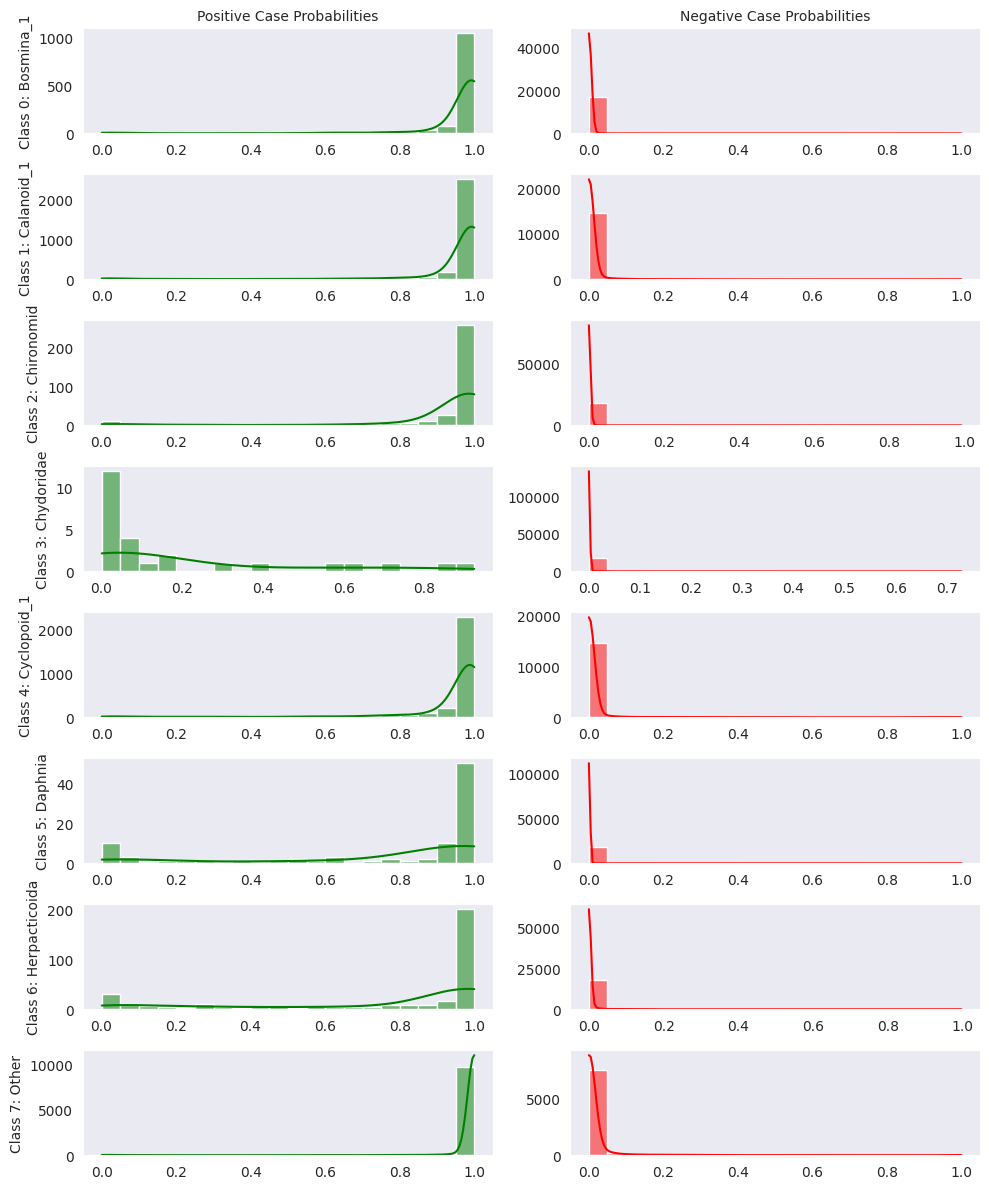

In [11]:
sns.set_style('dark')
fig, axs = plt.subplots(NUM_CLASSES, 2, figsize = (10, NUM_CLASSES * 1.5))

for i in range(NUM_CLASSES):
    positive_cases = np.where(np.array(marginal_labels[i]) == 1)
    positive_probs = np.array(marginal_probs[i])[positive_cases]

    negative_cases = np.where(np.array(marginal_labels[i]) == 0)
    negative_probs = np.array(marginal_probs[i])[negative_cases]

    sns.histplot(positive_probs, bins=20, ax=axs[i, 0], color='green', kde=True)
    sns.histplot(negative_probs, bins=20, ax=axs[i, 1], color='red', kde=True)

    axs[i, 0].set_ylabel(f'Class {i}: {class_map_rev[i]}', fontsize=10)
    axs[i, 0].set_xlabel('')
    axs[i, 1].set_ylabel('')
    axs[i, 1].set_xlabel('')

    if i == 0:
        axs[i, 0].set_title('Positive Case Probabilities', fontsize=10)
        axs[i, 1].set_title('Negative Case Probabilities', fontsize=10)

plt.tight_layout()
plt.show()

#### Calibration Curve

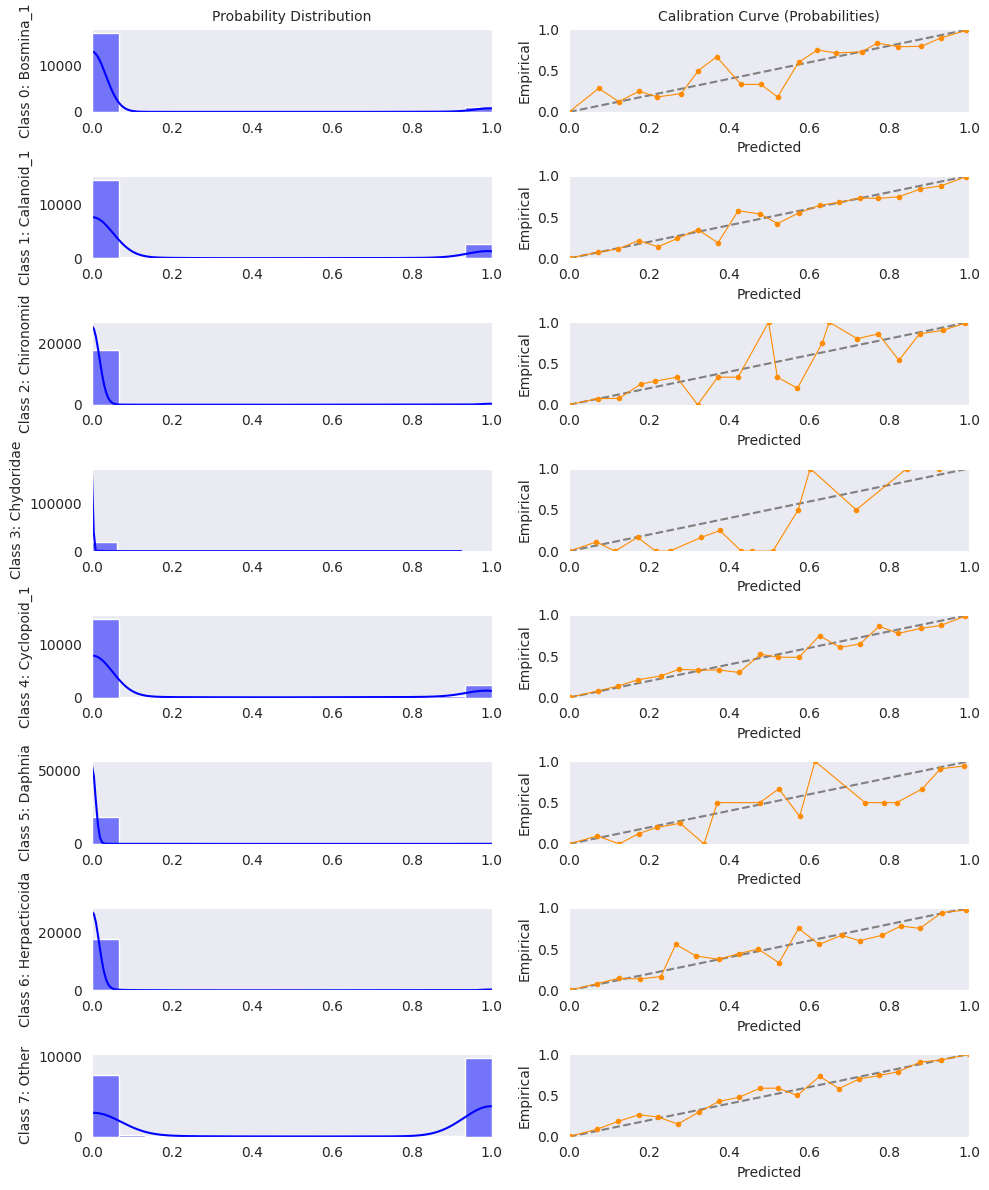

In [12]:
from sklearn.calibration import calibration_curve

fig, axs = plt.subplots(NUM_CLASSES, 2, figsize = (10, NUM_CLASSES * 1.5))

for i in range(NUM_CLASSES):

    prob_true, prob_pred = calibration_curve(
        marginal_labels[i], 
        marginal_probs[i], 
        n_bins = 20,
        strategy='uniform',
        pos_label = 1)


     # Left: histogram of predicted probabilities
    sns.histplot(marginal_probs[i], bins=15, kde=True, color='blue', ax=axs[i,0])
    axs[i,0].set_xlim(0,1)
    axs[i,0].set_ylabel(f'Class {i}: {class_map_rev[i]}', fontsize=10)

    # Right: calibration curve
    axs[i,1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axs[i,1].plot(prob_pred, prob_true, marker='o',  markersize=3, linewidth=0.8, color='darkorange')
    axs[i,1].set_xlim(0,1)
    axs[i,1].set_ylim(0,1)
    axs[i,1].set_xlabel("Predicted")
    axs[i,1].set_ylabel("Empirical")

    if i == 0:
        axs[i, 0].set_title('Probability Distribution', fontsize=10)
        axs[i, 1].set_title('Calibration Curve (Probabilities)', fontsize=10)

plt.tight_layout()
plt.show()
